In [1]:
from O.interface import *

/home/aidan/research/sim_files/FEcrys_fork/FEcrys/O/NN/model_helper.py:480: SyntaxWarning: invalid escape sequence '\p'
  incuA : (m,1) shaped array = \phi(r) = u(r) + ln(p(r)) ; r ~ \mu
2026-05-31 22:44:00.427061: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 22:44:00.436832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780289040.448204  440237 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780289040.451386  440237 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin 

# training on a laptop with CPU

In [2]:
# this dataset (veliparib_dataset_I_NVT_cell_111_CUT) will be included in the slightly larger version of repository 
# (that version of repository downloadable via the link in FEcrys/'About'; TODO)

# this dataset only has 60,000 MD samples, that are split 4:1 for training:validation, so only 48,000 training examples.

nn = NN_interface_sc_multimap(
                name = 'veliparib_I_111_trying_small_dataset',
                paths_datasets = ['./O/MM/GAFF_sc/veliparib/data/veliparib_dataset_I_NVT_cell_111_CUT',],
                running_in_notebook = True,
                training = True,
                model_class = PGMcrys_v1,
                identity_init=True
                )

# initialise_object (SingleComponent) with GAFF FF, from the input file (PDB):
 ./O//MM/GAFF_sc/veliparib/veliparib_I_equilibrated_cell_111.pdb
n_molecules: 8

# initialise_system:
set PME cutoff to: 0.36 nm
removeCMMotion active: True

__ changing n_mol in top: ________________________________
in the /home/aidan/research/sim_files/FEcrys_fork/FEcrys/O/MM/GAFF_sc/veliparib/misc/x_veliparib_gmx.top
replaced 1 line ( 399 ) 
 from: 
     UNK                  1
 to 
     UNK                  8
these changes were written into file: /home/aidan/research/sim_files/FEcrys_fork/FEcrys/O/MM/GAFF_sc/veliparib/misc/x_x_veliparib_gmx.top
__________________________________________________________

set SwitchingFunction to 0.95 * PME_cutoff = 0.34199999999999997 nm
adjusted EwaldErrorTolerance from 0.0005 to 0.0001
no corrections to self.system
n_mol =  8, n_atoms_mol = 34, N = 272, n_DOF = 813 (n_constraints = 3) 

# initialise_simulation:
set temperature: 300 Kelvin
set integration timestep: 0.002 

In [3]:
nn.set_ic_map_step1(ind_root_atom=5, option=0)

molecule with 34 atoms, of which 18 are heavy atoms, and the rest are 16 hydrogens.
atoms with incides [5, 10, 1] are set to be the Cartesian_Block
position of the molecule specified by atoms with index: 5
rotation of the molecule specified by atoms with indices: [10, 1]
conformation of the molecule specified by all other atoms.


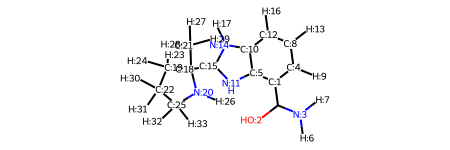

In [4]:
# [5, 10, 1] are carbon atoms of the large ring: 
# this is a user-defined choice, can by any rigid section of the molecule
# can try other options, and then absolute FEs might be slightly different, but FE difference within same n_mol should be the same.
nn.nns[0].sc.mol

In [5]:
nn.set_ic_map_step2(check_PES=True)

COM removed from data without taking into account PBC of the box
inds_rand attempt: 1
found !
checking that PES matches the sampled dataset:
errT: -0.00012192741187232059 -0.0036525365656530084 0.004040438872323193
errV: -6.96932107961743e-05 -0.0037902202821271658 0.0038627258896610783


In [6]:
# ! a much smaller dataset than used in the paper
# expecting overfitting to be quite rapid, while using a similar sized model.

nn.nns[0].r.shape, nn.nns[0].r_training.shape, nn.nns[0].r_validation.shape

((60000, 272, 3), (48000, 272, 3), (12000, 272, 3))

In [7]:
# n_mol_unitcells is another user choice in this version (default ic_map slightly different from the paper)

# the numbers printed below could be more informative, but in this case means that the methyl group hydrogens
# have three torsions, that are unconstrained in all molecules (model needs to learn not to clash them)

nn.set_ic_map_step3(n_mol_unitcells=[8,])

initialising on 60000 datapoints provided
SCmap.initalise_ : a single box provided -> Cartesian transformed by SCmap.
3 out of 248 potentially periodic marginal variables are set to periodic
This topology is shared over all molecules.

0 out of 8 potentially periodic marginal variables are set to periodic
This topology is shared over all molecules.

ic_map inversion errors on a small random batch:
positons: 5.275011e-05
volume: 0.00024414062
!! 1.0003321


In [8]:
nn.set_model(n_layers = 4, learning_rate=0.001, n_att_heads=4, evaluation_batch_size=5000)

# inv_test outputs are explained inside the code
# this output doesn't look ideal for the start of training (the last 3 numbers a bit high for this small system), but its fine here.

self.n_att_heads: 4
There are 9423080 trainable parameters in this model, among 324 trainable weights.
[To see dimensionalities of the trainable weights print(list(self.shapes_trainable_weights)).] 


<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:664: SyntaxWarning: invalid escape sequence '\p'
<unknown>:664: SyntaxWarning: invalid escape sequence '\p'
<unknown>:664: SyntaxWarning: invalid escape sequence '\p'
<unknown>:664: SyntaxWarning: invalid escape sequence '\p'
<unknown>:664: SyntaxWarning: invalid escape sequence '\p'


inv_test_res0 ([[np.float32(6.652232e-06), np.float32(6.2942505e-05)], [np.float32(-0.00012094727), np.float32(-0.00048828125), np.float32(0.00024414062)]], [[[np.float32(0.00024938534), np.float32(0.0020962358)], [np.float32(7.462858e-07), np.float32(1.1622906e-05)]], [np.float32(-0.00013740234), np.float32(-0.00048828125), np.float32(0.00024414062)]])


In [9]:
''' initialisation example '''

' initialisation example '

In [10]:
nn.set_trainer(n_batches_between_evaluations=50)

''

In [11]:
nn.train(   n_batches = 0,
            save_misc = True,
            save_BAR = True,

            evaluate_on_training_data = True, # *also on training data. very optional just to see overfit BAR (i.e., BAR_T)
            test_inverse = True,              # optional
            f_halfwindow_visualisation = [2.5, 1.],
        )

training time so far: 0.0 minutes
saved ./O//NN/training_results/misc/veliparib_I_111_trying_small_dataset_SC__misc_
misc training outputs were saved
saved ./O//NN/training_results/misc/veliparib_I_111_trying_small_dataset_SC__inv_test_
inv_test results were saved


### Test saving and loading in new env

In [12]:
# Test saving and loading in new env
nn.save_model_()

saved ./O//NN/training_results/fitted_models/veliparib_I_111_trying_small_dataset_SC__model_


In [13]:
nn_load = NN_interface_sc_multimap(
                name = 'veliparib_I_111_trying_small_dataset',
                paths_datasets = ['./O/MM/GAFF_sc/veliparib/data/veliparib_dataset_I_NVT_cell_111_CUT',],
                running_in_notebook = True,
                training = True,
                model_class = PGMcrys_v1,
                identity_init=True
                )

nn_load.load_model_()

# initialise_object (SingleComponent) with GAFF FF, from the input file (PDB):
 ./O//MM/GAFF_sc/veliparib/veliparib_I_equilibrated_cell_111.pdb
n_molecules: 8

# initialise_system:
set PME cutoff to: 0.36 nm
removeCMMotion active: True

__ changing n_mol in top: ________________________________
in the /home/aidan/research/sim_files/FEcrys_fork/FEcrys/O/MM/GAFF_sc/veliparib/misc/x_veliparib_gmx.top
replaced 1 line ( 399 ) 
 from: 
     UNK                  1
 to 
     UNK                  8
these changes were written into file: /home/aidan/research/sim_files/FEcrys_fork/FEcrys/O/MM/GAFF_sc/veliparib/misc/x_x_veliparib_gmx.top
__________________________________________________________

set SwitchingFunction to 0.95 * PME_cutoff = 0.34199999999999997 nm
adjusted EwaldErrorTolerance from 0.0005 to 0.0001
no corrections to self.system
n_mol =  8, n_atoms_mol = 34, N = 272, n_DOF = 813 (n_constraints = 3) 

# initialise_simulation:
set temperature: 300 Kelvin
set integration timestep: 0.002 

### Test the untrained mapping

In [22]:
with open("./O/MM/GAFF_sc/veliparib/data/veliparib_dataset_I_NVT_cell_111_CUT", 'rb') as f:
    data = pickle.load(f)

nsamps = 10
samps = data['MD dataset']['xyz'][:nsamps]

mapped_samps, mapped_ladj = nn_load.model.forward(samps)
print(np.shape(mapped_samps[0]))

(10, 21)
